# Sanskrit Kavya Sound Pattern Analysis

This notebook performs a comprehensive analysis of sound patterns in Sanskrit kavyas. It combines:

1. Sound clustering to identify groups of kavyas with similar phonetic patterns
2. Feature importance analysis to determine which sounds are most distinctive between clusters

The analysis helps us understand how different works and authors may have distinctive sound patterns.

## Setup and Data Loading

First, we import the necessary libraries and load our dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import matplotlib.cm as cm
from scipy.cluster.hierarchy import dendrogram, linkage
from indic_transliteration.sanscript import transliterate, IAST, DEVANAGARI, ITRANS

# Set up matplotlib for better rendering in notebook
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

Now let's load the dataset containing the normalized sound frequencies in various Sanskrit kavyas.

In [ ]:
# Load the data
cols_devn_to_iast= {
    'अ': 'm_a', 'आ': 'm_ā', 'इ': 'm_i', 'ई': 'm_ī', 'उ': 'm_u', 'ऊ': 'm_ū', 
    'ऋ': 'm_ṛ', 'ॠ': 'm_ṝ',  
    'ए': 'm_e', 'ऐ': 'm_ai', 'ओ': 'm_o', 'औ': 'm_au',
    'क्': 'ṃ_k', 'ख्': 'ṃ_kh', 'ग्': 'ṃ_g', 'घ्': 'ṃ_gh', 'ङ्': 'ṃ_ṅ',
    'च्': 'ṃ_c', 'छ्': 'ṃ_ch', 'ज्': 'ṃ_j', 'झ्': 'ṃ_jh', 'ञ्': 'ṃ_ñ',
    'ट्': 'ṃ_ṭ', 'ठ्': 'ṃ_ṭh', 'ड्': 'ṃ_ḍ', 'ढ्': 'ṃ_ḍh', 'ण्': 'ṃ_ṇ',
    'त्': 'ṃ_t', 'थ्': 'ṃ_th', 'द्': 'ṃ_d', 'ध्': 'ṃ_dh', 'न्': 'ṃ_n',
    'प्': 'ṃ_p', 'फ्': 'ṃ_ph', 'ब्': 'ṃ_b', 'भ्': 'ṃ_bh', 'म्': 'ṃ_m',
    'य्': 'ṃ_y', 'र्': 'ṃ_r', 'ल्': 'ṃ_l', 'व्': 'ṃ_v', 
    'श्': 'ṃ_ś', 'ष्': 'ṃ_ṣ', 'स्': 'ṃ_s',
    'ह्': 'ṃ_h',
}


def load_data(file_path='msound_normalized.csv'):
    """
    Load the dataset from a CSV file.
    The dataset should be normalized and ready for analysis.
    """
    try:
        data = pd.read_csv(file_path)
        print("Data loaded successfully.")
        return data
    except FileNotFoundError:
        print(f"File not found. Please ensure '{file_path}' is in the current directory.")
        return None

        return None
sanchaya_data = load_data('msound_normalized.csv')
gretil_data = load_data('gmsound_normalized.csv')
gretil_iast_cols = [transliterate(col, DEVANAGARI, IAST) for col in gretil_data.columns]
gretil_devn_cols = ['kavya'] + ([transliterate(col[2:], IAST, DEVANAGARI)+f"({col})" for col in gretil_data.columns[1:]])
gretil_data.columns = gretil_devn_cols
# sort the non-kavya columns for better readability
gretil_data = gretil_data[['kavya'] + sorted(gretil_data.columns[1:])]

# Display the first few rows of the dataset
display(sanchaya_data.head().style.set_properties(**{'text-align': 'left'}))
display(gretil_data.head().style.set_properties(**{'text-align': 'left'}))

Data loaded successfully.
Data loaded successfully.


,kavya,अ,आ,इ,ई,उ,ऊ,ऋ,ए,ऐ,ओ,औ,क्,ख्,ग्,घ्,ङ्,च्,छ्,ज्,झ्,ञ्,ट्,ठ्,ड्,ढ्,ण्,त्,थ्,द्,ध्,न्,प्,फ्,ब्,भ्,म्,य्,र्,ल्,व्,श्,ष्,स्,ह्
0,aryabhatiya,0.127273,0.004545,0.013636,0.000000,0.031818,0.000000,0.022727,0.004545,0.000000,0.000000,0.000000,0.054545,0.009091,0.045455,0.009091,0.000000,0.054545,0.009091,0.009091,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.063636,0.000000,0.040909,0.013636,0.022727,0.059091,0.004545,0.018182,0.040909,0.036364,0.040909,0.013636,0.018182,0.054545,0.040909,0.004545,0.127273,0.004545
1,ashtanga_hrud,0.000731,0.000219,0.000000,0.000000,0.000146,0.000073,0.000073,0.000000,0.000000,0.000000,0.000000,0.077592,0.003288,0.024257,0.011105,0.000000,0.091839,0.003215,0.018923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.094323,0.000000,0.041791,0.008037,0.041353,0.113685,0.003434,0.019946,0.018850,0.058230,0.029955,0.026083,0.015489,0.110543,0.051509,0.001973,0.107693,0.025645
2,bharata_natya,0.080179,0.026561,0.024327,0.001738,0.028050,0.002234,0.001365,0.048281,0.000000,0.000496,0.000621,0.061685,0.001489,0.018369,0.002110,0.000000,0.094328,0.002482,0.010674,0.000124,0.000000,0.000000,0.000000,0.000248,0.000000,0.000000,0.107608,0.000000,0.027305,0.003351,0.052997,0.092094,0.000869,0.016011,0.033263,0.021348,0.026064,0.011667,0.009681,0.070498,0.018741,0.001738,0.084399,0.017004
3,bhasa_svapna,0.041965,0.017400,0.025589,0.001024,0.011259,0.000000,0.000000,0.013306,0.000000,0.000000,0.000000,0.092119,0.018424,0.029683,0.003071,0.000000,0.029683,0.000000,0.019447,0.000000,0.000000,0.000000,0.001024,0.000000,0.000000,0.035824,0.051177,0.000000,0.053224,0.005118,0.058342,0.114637,0.000000,0.012282,0.078813,0.061412,0.005118,0.022518,0.004094,0.081883,0.024565,0.001024,0.070624,0.015353
4,gaarg,0.004237,0.003390,0.000678,0.000000,0.003220,0.000339,0.000508,0.001525,0.000169,0.000000,0.000000,0.070508,0.000508,0.027458,0.003729,0.000000,0.116949,0.001695,0.024915,0.000000,0.000000,0.000169,0.000000,0.000339,0.000000,0.000000,0.094407,0.000000,0.045932,0.009153,0.054576,0.099322,0.003729,0.020847,0.044407,0.036610,0.040169,0.018305,0.007458,0.124237,0.038814,0.001695,0.085932,0.014068


,kavya,ं(ṃ_ṃ),ः(ṃ_ḥ),अ(m_a),आ(m_ā),इ(m_i),ई(m_ī),उ(m_u),ऊ(m_ū),ऋ(m_ṛ),ए(m_e),ऐ(m_ai),ओ(m_o),औ(m_au),क्(ṃ_k),ख्(ṃ_kh),ग्(ṃ_g),घ्(ṃ_gh),ङ्(ṃ_ṅ),च्(ṃ_c),छ्(ṃ_ch),ज्(ṃ_j),झ्(ṃ_jh),ञ्(ṃ_ñ),ट्(ṃ_ṭ),ठ्(ṃ_ṭh),ड्(ṃ_ḍ),ढ्(ṃ_ḍh),ण्(ṃ_ṇ),त्(ṃ_t),थ्(ṃ_th),द्(ṃ_d),ध्(ṃ_dh),न्(ṃ_n),प्(ṃ_p),फ्(ṃ_ph),ब्(ṃ_b),भ्(ṃ_bh),म्(ṃ_m),य्(ṃ_y),र्(ṃ_r),ल्(ṃ_l),व्(ṃ_v),श्(ṃ_ś),ष्(ṃ_ṣ),स्(ṃ_s),ह्(ṃ_h),ॠ(m_ṝ)
0,108-buddhist-stotras,0.000000,0.000000,0.126582,0.113924,0.000000,0.012658,0.075949,0.000000,0.000000,0.012658,0.012658,0.012658,0.012658,0.025316,0.012658,0.012658,0.000000,0.000000,0.037975,0.000000,0.012658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.025316,0.000000,0.012658,0.000000,0.101266,0.063291,0.012658,0.025316,0.025316,0.037975,0.012658,0.012658,0.000000,0.037975,0.025316,0.000000,0.088608,0.037975,0.000000
1,AGgirasasmRti,0.000000,0.000000,0.029218,0.007069,0.000943,0.000000,0.001885,0.000000,0.000000,0.005655,0.000000,0.000000,0.000943,0.068803,0.000471,0.022149,0.001885,0.000000,0.068803,0.000000,0.014138,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.138077,0.000000,0.042884,0.009425,0.054194,0.122997,0.001885,0.044769,0.034873,0.031103,0.040999,0.007540,0.006126,0.081998,0.035815,0.004241,0.108388,0.012724,0.000000
2,AdizeSa-paramArthasAra,0.000000,0.000000,0.185567,0.051546,0.123711,0.000000,0.061856,0.000000,0.000000,0.082474,0.010309,0.000000,0.000000,0.030928,0.000000,0.010309,0.000000,0.000000,0.000000,0.000000,0.030928,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020619,0.000000,0.020619,0.000000,0.051546,0.072165,0.000000,0.041237,0.020619,0.010309,0.041237,0.000000,0.000000,0.061856,0.030928,0.000000,0.041237,0.000000,0.000000
3,AdyanAtha-anuttaraprakAzapaJcAzikA,0.000000,0.000000,0.152174,0.043478,0.130435,0.043478,0.043478,0.021739,0.000000,0.086957,0.000000,0.000000,0.000000,0.000000,0.000000,0.021739,0.000000,0.000000,0.021739,0.000000,0.021739,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021739,0.000000,0.000000,0.000000,0.021739,0.043478,0.000000,0.065217,0.043478,0.043478,0.021739,0.021739,0.021739,0.021739,0.021739,0.000000,0.065217,0.000000,0.000000
4,AlambanaparIkSA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,0.111111,0.000000,0.222222,0.111111,0.111111,0.000000,0.000000,0.000000,0.111111,0.111111,0.000000,0.111111,0.000000,0.000000


In [ ]:
sanchaya_to_gretil = {
 'aryabhatiya': 'AryabhaTa-AryabhaTIya',
 'ashtanga_hrud': 'vAgbhaTa-aSTAGgahRdayasUtra',
 'bharata_natya': 'bharata-nATyazAstra-1-1618-303335-37',
 'bhasa_svapna': 'bhAsa-svapnavAsavadatta',
 'gaarg': None,
 'gita_govinda': 'jayadeva-gItagovinda',
 'kiratarjuniya': 'bhAravi-kirAtArjunIya',
 'kumarasambhava': 'kAlidAsa-kumArasaMbhava',
 'madhuravijaya': 'samAdhirAjasUtra',
 'meghadutam': 'kAlidAsa-meghadUta',
 'mrcc_dev': None,
 'mudra_raks': None,
 'naishadiya': None,
 'raghuvamsham': 'kAlidAsa-raghuvaMza',
 'ratnavali': 'harSadeva-ratnAvalInATikA',
 'sahrudaya': 'Anandavardhana-dhvanyAloka-comm',
 'shakuntalam': 'kAlidAsa-abhijJAnazakuntala',
 'shishupala': 'mAgha-zizupAlavadha',
 'tarkasangraha': 'annaMbhatta-tarkasaMgraha',
 'udayana': 'udayana-nyAyakusumAJjali',
 'yougandharayanam': None
 }


selected_gretils = [v for k,v in sanchaya_to_gretil.items() if v is not None and "comm" not in v]
selected_gretils_data = gretil_data[gretil_data['kavya'].isin(selected_gretils)]
# display shape of the selected data



Selected Gretil data shape: (15, 48)


# MARKER: Need to parameterize code below this cell to run on different datasets

In [35]:
# Compute variances for each column
df = sanchaya_data.copy()
# df.columns = devn_cols
df = df.set_index('kavya')
variances = df.var()

# Sort columns by variance
sorted_columns = variances.sort_values(ascending=False).index

# Reorder the DataFrame
df_sorted = df[sorted_columns]

# value_counts = df_sorted.stack().value_counts()
# # Map each cell to its frequency
# freq_df = df_sorted.applymap(lambda val: value_counts.get(val, 0))
# # Get global min and max for the color scale
# vmin = freq_df.min().min()
# vmax = freq_df.max().max()

display(

df_sorted.iloc[:,:].map(lambda x: round(100*x,0)).style.background_gradient(
    'Reds',
    vmin=1, 
    vmax=25, 
    subset=df.columns, 
#     gmap=freq_df
).format("{:.0f}"
).set_table_styles([
            {'selector': 'th.col_heading', 
             'props': 'transform: rotate(0deg) translate(-5px, -75px); height: 90px; vertical-align: bottom; white-space: wrap; font-size: 12px; color:blue'},
            {'selector': 'td', 
             'props': 'white-space: nowrap; padding: 0px 4px; font-size: 12px; color: ivory;'},
            {'selector': 'th.row_heading',
             'props': 'white-space: nowrap; padding: 0px 4px; font-size: 12px;'},
            {'selector': 'tbody', 
             'props': 'transform:translate(-1px, -105px)'},
            {'selector': 'thead th', 
             'props': 'min-width: 14px; max-width: 20px;'}
        ]).set_caption("<h2>Colored across all scores</h2>")
,
df_sorted.iloc[:,:].map(lambda x: round(100*x,0)).style.background_gradient(
    'YlOrRd',
).format("{:.0f}"
).set_table_styles([
            {'selector': 'th.col_heading', 
             'props': 'transform: rotate(0deg) translate(-5px, -75px); height: 90px; vertical-align: bottom; white-space: wrap; font-size: 12px; color:blue'},
            {'selector': 'td', 
             'props': 'white-space: nowrap; padding: 0px 4px; font-size: 12px; color: ivory;'},
            {'selector': 'th.row_heading',
             'props': 'white-space: nowrap; padding: 0px 4px; font-size: 12px;'},
            {'selector': 'tbody', 
             'props': 'transform:translate(-1px, -105px)'},
            {'selector': 'table', 
             'props': 'table-layout: fixed; width: auto;'},
            {'selector': 'thead th', 
             'props': 'min-width: 14px; max-width: 20px;'}
        ]).set_caption('<h2>Column wise coloring</h2>')
    
)


,अ,च्,प्,इ,आ,स्,त्,व्,भ्,क्,उ,म्,न्,द्,ग्,य्,ज्,ण्,ए,श्,र्,ह्,ऋ,ख्,ब्,ध्,ल्,घ्,ई,फ्,छ्,ष्,ऊ,ऐ,झ्,औ,ओ,ड्,ट्,ठ्,थ्,ढ्,ङ्,ञ्
kavya,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
aryabhatiya,13,5,6,1,0,13,6,5,4,5,3,4,2,4,5,4,1,0,0,4,1,0,2,1,2,1,2,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
ashtanga_hrud,0,9,11,0,0,11,9,11,2,8,0,6,4,4,2,3,2,0,0,5,3,3,0,0,2,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
bharata_natya,8,9,9,2,3,8,11,7,3,6,3,2,5,3,2,3,1,0,5,2,1,2,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
bhasa_svapna,4,3,11,3,2,7,5,8,8,9,1,6,6,5,3,1,2,4,1,2,2,2,0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
gaarg,0,12,10,0,0,9,9,12,4,7,0,4,5,5,3,4,2,0,0,4,2,1,0,0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
gita_govinda,24,3,6,9,2,4,5,6,2,5,5,3,2,3,4,2,2,0,2,2,3,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
kiratarjuniya,18,1,7,8,6,5,4,8,2,3,6,4,6,3,2,1,2,0,2,2,1,1,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
kumarasambhava,18,3,8,5,8,6,5,7,1,5,5,4,5,3,2,2,1,0,3,2,1,2,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
madhuravijaya,4,3,9,2,2,8,5,9,2,9,1,7,9,5,3,2,2,0,1,4,3,4,0,0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,अ,च्,प्,इ,आ,स्,त्,व्,भ्,क्,उ,म्,न्,द्,ग्,य्,ज्,ण्,ए,श्,र्,ह्,ऋ,ख्,ब्,ध्,ल्,घ्,ई,फ्,छ्,ष्,ऊ,ऐ,झ्,औ,ओ,ड्,ट्,ठ्,थ्,ढ्,ङ्,ञ्
kavya,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
aryabhatiya,13,5,6,1,0,13,6,5,4,5,3,4,2,4,5,4,1,0,0,4,1,0,2,1,2,1,2,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
ashtanga_hrud,0,9,11,0,0,11,9,11,2,8,0,6,4,4,2,3,2,0,0,5,3,3,0,0,2,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
bharata_natya,8,9,9,2,3,8,11,7,3,6,3,2,5,3,2,3,1,0,5,2,1,2,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
bhasa_svapna,4,3,11,3,2,7,5,8,8,9,1,6,6,5,3,1,2,4,1,2,2,2,0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
gaarg,0,12,10,0,0,9,9,12,4,7,0,4,5,5,3,4,2,0,0,4,2,1,0,0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
gita_govinda,24,3,6,9,2,4,5,6,2,5,5,3,2,3,4,2,2,0,2,2,3,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
kiratarjuniya,18,1,7,8,6,5,4,8,2,3,6,4,6,3,2,1,2,0,2,2,1,1,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
kumarasambhava,18,3,8,5,8,6,5,7,1,5,5,4,5,3,2,2,1,0,3,2,1,2,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
madhuravijaya,4,3,9,2,2,8,5,9,2,9,1,7,9,5,3,2,2,0,1,4,3,4,0,0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Data Preparation for Clustering

Let's prepare our data for clustering by extracting the kavya names and sound frequencies.

In [25]:
# Extract kavya names for later use
kavya_names = data['kavya'].values

# Extract sound frequencies (features) for clustering
X = data.drop('kavya', axis=1)

# Standardize the data (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Number of kavyas: {len(kavya_names)}")
print(f"Number of sound features: {X.shape[1]}")

Number of kavyas: 21
Number of sound features: 44


/Users/sunder/miniforge3/envs/tfmetal/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/sunder/miniforge3/envs/tfmetal/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/sunder/miniforge3/envs/tfmetal/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/sunder/miniforge3/envs/tfmetal/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and

## Determining the Optimal Number of Clusters

We'll use silhouette scores to determine the optimal number of clusters for our data.

K=2, Silhouette Score: 0.1355
K=3, Silhouette Score: 0.1693
K=4, Silhouette Score: 0.1371
K=5, Silhouette Score: 0.1425
K=6, Silhouette Score: 0.1534
K=7, Silhouette Score: 0.1601
K=8, Silhouette Score: 0.1582
K=9, Silhouette Score: 0.1532


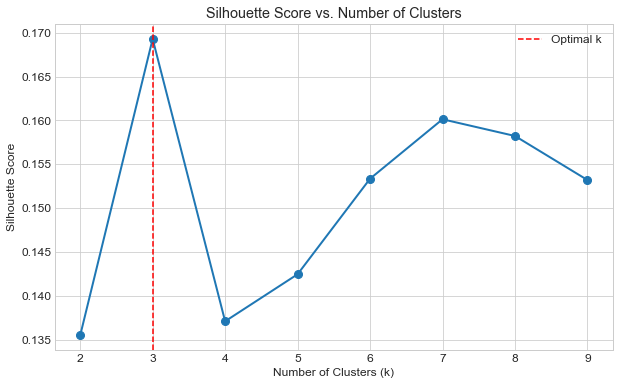


Optimal number of clusters based on silhouette score: 3


In [26]:
# Determine optimal number of clusters using silhouette scores
sil_scores = []
K_range = range(2, 10)  # Try cluster sizes from 2 to 9

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    sil_scores.append(sil_score)
    print(f"K={k}, Silhouette Score: {sil_score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, sil_scores, 'o-', linewidth=2, markersize=8)
# color the peak red
plt.axvline(x=K_range[np.argmax(sil_scores)], color='red', linestyle='--', label='Optimal k')
plt.legend()
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.grid(True)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Force integer ticks on x-axis

# save as silhouette_scores.png
plt.savefig('silhouette_scores.png', dpi=300)
plt.show()

# Choose optimal number of clusters based on the highest silhouette score
optimal_k = K_range[np.argmax(sil_scores)]
print(f"\nOptimal number of clusters based on silhouette score: {optimal_k}")

## K-means Clustering with Optimal K

Let's perform K-means clustering with the optimal number of clusters determined above.

In [27]:
# Perform K-means clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Create a DataFrame with the cluster labels
kavya_df = pd.DataFrame({'kavya': kavya_names, 'cluster': labels})

# Display kavyas by cluster
for cluster in range(optimal_k):
    print(f"\nCluster {cluster + 1}:")
    cluster_kavyas = kavya_df[kavya_df['cluster'] == cluster]['kavya'].values
    print(", ".join(cluster_kavyas))


Cluster 1:
bharata_natya, gita_govinda, kiratarjuniya, kumarasambhava, meghadutam, mudra_raks, naishadiya, raghuvamsham, shakuntalam

Cluster 2:
bhasa_svapna, mrcc_dev, ratnavali, yougandharayanam

Cluster 3:
aryabhatiya, ashtanga_hrud, gaarg, madhuravijaya, sahrudaya, shishupala, tarkasangraha, udayana


## Principal Component Analysis (PCA) for Visualization

Now we'll use PCA to reduce our high-dimensional data to 2D for visualization.

In [28]:
# Apply PCA for dimensionality reduction to visualize in 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Percentage of variance explained by each principal component
explained_variance = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_variance[0]:.4f}")
print(f"Variance explained by PC2: {explained_variance[1]:.4f}")
print(f"Total variance explained: {sum(explained_variance):.4f}")

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': labels,
    'Kavya': kavya_names
})


Variance explained by PC1: 0.2400
Variance explained by PC2: 0.1625
Total variance explained: 0.4024


## Visualizing Kavya Clusters in 2D Space

Let's create a visualization of the kavya clusters in the 2D space of the top two principal components.

/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_53605/3743195689.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('rainbow', n_cluster)  # Use a colormap with enough distinct colors


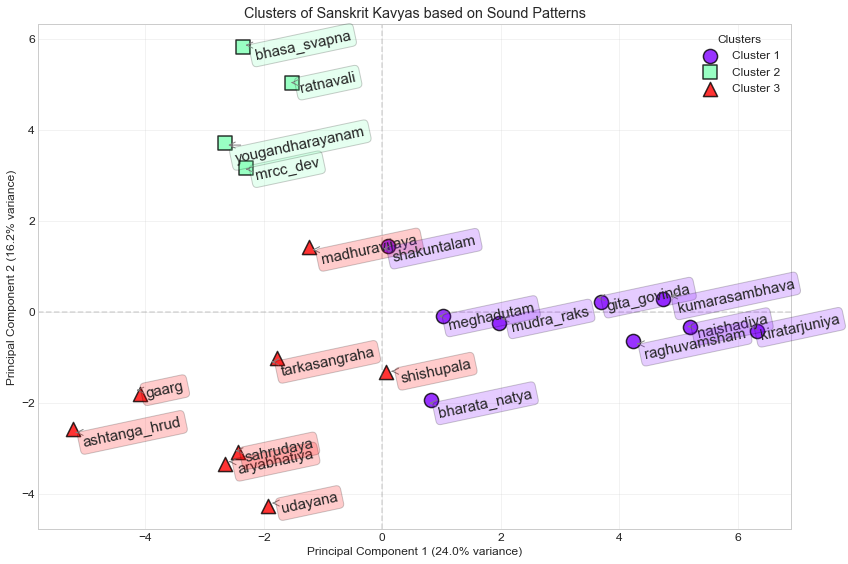

In [29]:
# Create the plot
import random
plt.figure(figsize=(12, 8))
# plt.figure(figsize=(14, 10))

for n_cluster in [optimal_k, 7][0:1] :
    colors = cm.get_cmap('rainbow', n_cluster)  # Use a colormap with enough distinct colors
    markers = ['o', 's', '^', 'D', 'v', 'x', 'p', '*', 'h']  # Different markers for each cluster
    # Set the color palette for clusters

    # Plot each cluster with a different color
    for cluster in range(n_cluster):
        cluster_data = plot_df[plot_df['Cluster'] == cluster]
        plt.scatter(
            cluster_data['PC1'], 
            cluster_data['PC2'], 
            s=200, 
            alpha=0.8,
            color=colors(cluster),
            edgecolor='black',
            linewidth=1.5,
            marker=markers[cluster % len(markers)],
            label=f'Cluster {cluster+1}'
        )

    # Add labels to points
    for i, row in plot_df.iterrows():
        plt.annotate(
            row['Kavya'], 
            (row['PC1'] + random.uniform(-0.1, 0.1), row['PC2'] + random.uniform(-0.1, 0.1)),
            fontsize=15,
            # rotation=20* (row['PC1'] + row['PC2']) / 10,  # Rotate based on position
            rotation=12+0*(row['Cluster']-1) ,  # Rotate based on cluster
            xytext=(8, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            # bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7),
            bbox=dict(boxstyle='round,pad=0.3', fc=colors(row['Cluster']), alpha=0.2),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='gray')
        )
        
    plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1%} variance)')
    plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1%} variance)')
    plt.title('Clusters of Sanskrit Kavyas based on Sound Patterns')
    plt.legend(title='Clusters')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    # save as kavya_clusters_pca.png
    plt.tight_layout()
    plt.savefig('kavya_clusters_pca.png', dpi=300)
    # plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Force integer ticks on x-axis
    # plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))  # Force integer ticks on y-axis
    plt.show()

## Analyzing Cluster Centers

Let's analyze what makes each cluster distinctive by examining the cluster centers in the original feature space.

In [30]:
# Get the cluster centers in the original feature space
from IPython.display import display, HTML

centers = kmeans.cluster_centers_

# Inverse transform the centers to get back to the original scale
centers_original = scaler.inverse_transform(centers)

# Create a DataFrame with the original feature names to analyze cluster centers
centers_df = pd.DataFrame(centers_original, columns=X.columns)

# Display the top 10 most dominant sounds for each cluster
print("Top 10 most dominant sounds in each cluster:")
for i in range(optimal_k):
    top_sounds = centers_df.iloc[i].sort_values(ascending=False).head(10)
    display(
        HTML(f"<b>Cluster {i+1}:</b>"),
        pd.DataFrame(top_sounds).T.style.format("{:.3f}").background_gradient(cmap='viridis', axis=1)
    )

Top 10 most dominant sounds in each cluster:


,a,p,s,v,t,n,i,k,ā,m
0,0.163,0.077,0.066,0.066,0.060,0.056,0.053,0.051,0.048,0.045


,p,k,s,v,d,t,n,m,bh,g
1,0.123,0.080,0.078,0.071,0.063,0.059,0.058,0.056,0.055,0.044


,p,s,v,t,k,c,a,n,d,m
2,0.101,0.098,0.088,0.082,0.071,0.067,0.058,0.057,0.040,0.038


## Heatmap of Cluster Centers

Let's visualize the sound frequencies in each cluster using a heatmap.

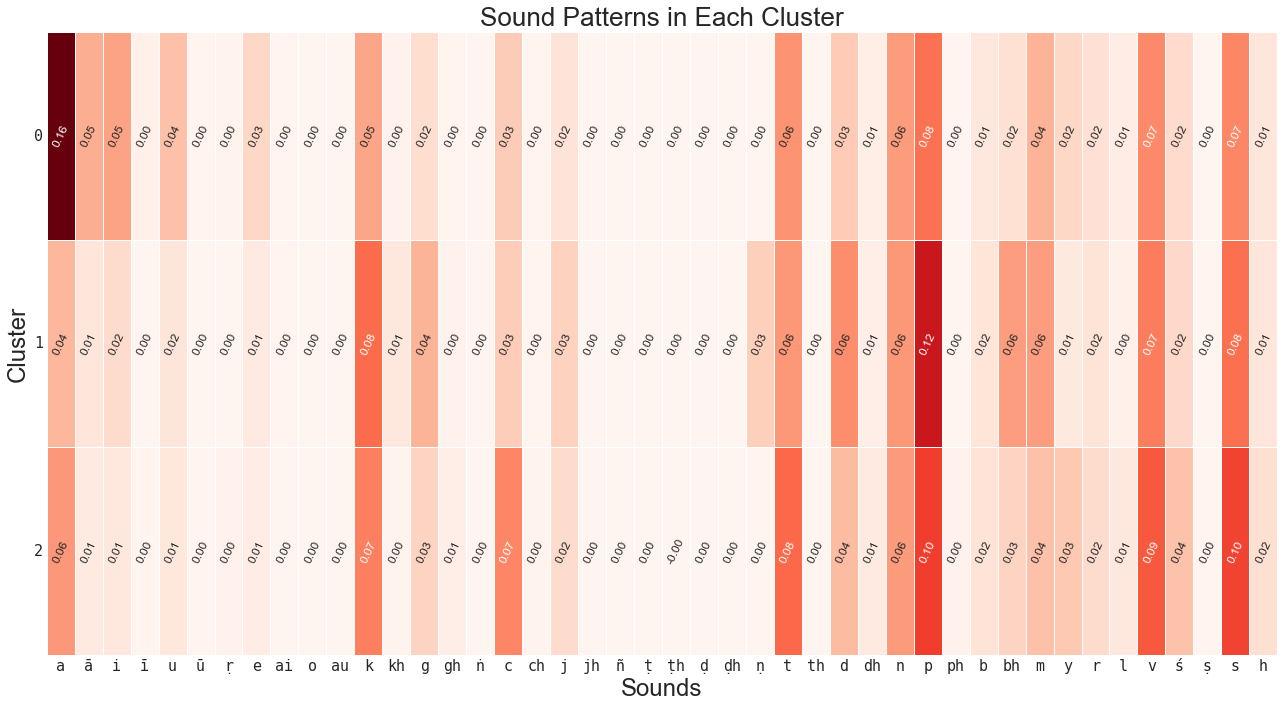

In [31]:
# Create a heatmap of cluster centers
plt.figure(figsize=(18, 10))
sns.heatmap(centers_df,
            cmap='Reds', 
            annot=True, fmt='.2f',
            annot_kws={"rotation": 65, 'fontsize': 12},
            cbar=False,
            cbar_kws={'label': 'Normalized Sound Frequency', 
                      'orientation': 'vertical'},
            linewidths=.5,  
)
plt.title('Sound Patterns in Each Cluster', fontsize=26)
plt.xlabel('Sounds', fontsize=24)
plt.ylabel('Cluster', fontsize=24)
plt.xticks(rotation=0, fontsize=15, fontfamily='Monospace')
plt.yticks(rotation=0, fontsize=15, fontfamily='Monospace')
# Save the heatmap
plt.savefig('cluster_centers_heatmap.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

## Feature Importance Analysis

Let's visualize the kavya clusters with the top contributing sound features in the PCA space.

/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_53605/2857263183.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('rainbow', optimal_k)  # Use a colormap with enough distinct colors


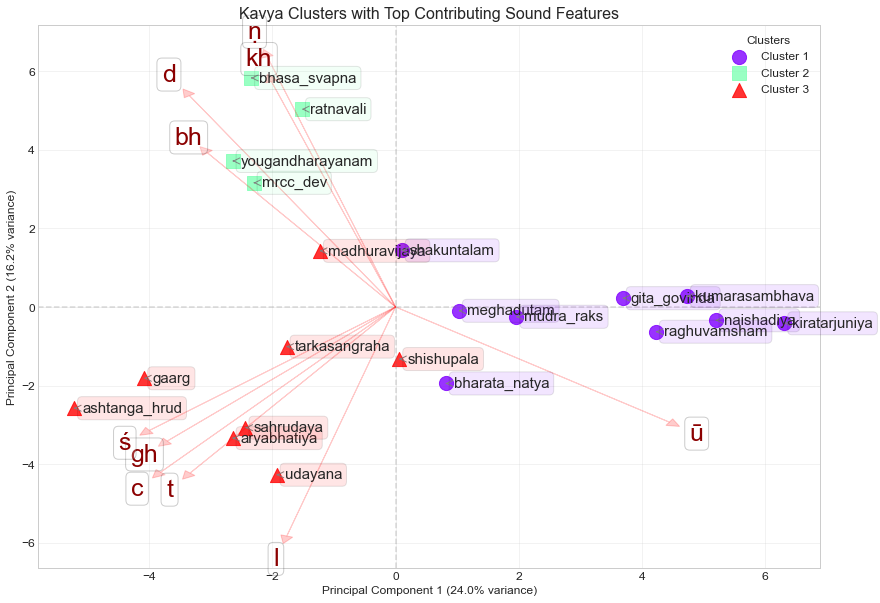

In [32]:
# Visualize kavyas with feature vectors
plt.figure(figsize=(14, 10))
colors = cm.get_cmap('rainbow', optimal_k)  # Use a colormap with enough distinct colors
markers = ['o', 's', '^', 'D', 'v', 'x', 'p', '*', 'h']  # Different markers for each cluster

# Create a scatter plot with color-coded clusters
for cluster in range(optimal_k):
    cluster_data = plot_df[plot_df['Cluster'] == cluster]
    plt.scatter(
        cluster_data['PC1'], 
        cluster_data['PC2'], 
        s=200, 
        alpha=0.8, 
        label=f'Cluster {cluster+1}',
        color=colors(cluster),
        marker=markers[cluster % len(markers)]  # Cycle through markers 
    )

# Add labels with line connections
for i, row in plot_df.iterrows():
    plt.annotate(
        row['Kavya'], 
        (row['PC1'], row['PC2']),
        fontsize=15,
        xytext=(8, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        bbox=dict(boxstyle='round,pad=0.3', fc=colors(row['Cluster']), alpha=0.1),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='gray')
    )

# Add feature vectors (eigenvectors scaled by eigenvalues)
feature_names = X.columns
feature_vectors = np.transpose(pca.components_)
feature_importance = np.abs(feature_vectors)

# Find top 10 most important features based on magnitude in PC space
top_features_idx = np.argsort(np.sum(feature_importance, axis=1))[-10:]
top_features = [feature_names[i] for i in top_features_idx]

scaling_factor = 5+5+5  # Adjust this value to scale the arrows appropriately
x_scaling_factor = 4*5  # Adjust this value to scale the x-component of arrows
y_scaling_factor = 4*5  # Adjust this value to scale the y-component of arrows
for i in top_features_idx:
    plt.arrow(0, 0, 
              pca.components_[0, i] * x_scaling_factor, 
              pca.components_[1, i] * y_scaling_factor, 
              head_width=0.2, 
              head_length=0.2, 
              fc='red', 
              ec='red', 
              alpha=0.2)
    plt.text(pca.components_[0, i] * x_scaling_factor * 1.1, 
             pca.components_[1, i] * y_scaling_factor * 1.1, 
             feature_names[i], 
             fontsize=25, 
             color='darkred', 
             ha='center', 
             va='center',
             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.2))

plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1%} variance)')
plt.title('Kavya Clusters with Top Contributing Sound Features', fontsize=16)
plt.legend(title='Clusters')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.savefig('kavya_clusters_with_features.png', bbox_inches='tight')

## Identifying Most Discriminative Sounds

Let's identify which sounds are most important in distinguishing between the clusters.

/Users/sunder/miniforge3/envs/tfmetal/lib/python3.9/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/sunder/miniforge3/envs/tfmetal/lib/python3.9/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/sunder/miniforge3/envs/tfmetal/lib/python3.9/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


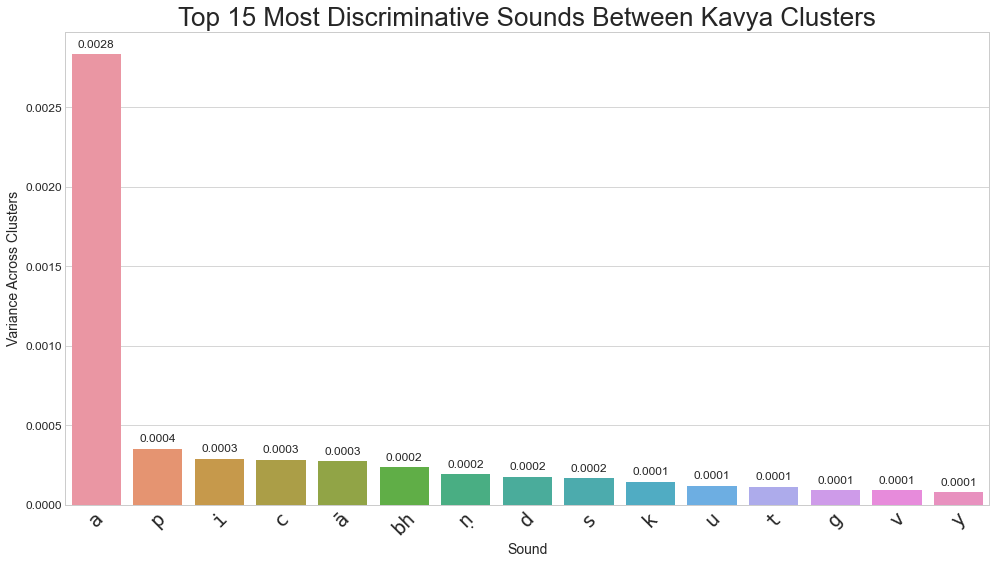

In [33]:
# Find the most discriminative features (sounds)
# Calculate the variance of each sound across cluster centers
feature_variance = pd.DataFrame({
    'sound': X.columns,
    'variance': np.var(centers_original, axis=0)
})

# Sort features by variance (higher variance means more discriminative)
top_features = feature_variance.sort_values(by='variance', ascending=False).head(15)

# Create a bar plot of the most discriminative features
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='sound', y='variance', data=top_features)
plt.title('Top 15 Most Discriminative Sounds Between Kavya Clusters', fontsize=26)
plt.xlabel('Sound', fontsize=14)
plt.ylabel('Variance Across Clusters', fontsize=14)
plt.xticks(rotation=45, fontsize=20, fontfamily='Monospace')

# Add value labels above each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), 
                textcoords = 'offset points')
    
# save discriminative_sounds.png
plt.savefig('discriminative_sounds.png', dpi=300 , bbox_inches='tight')

plt.tight_layout()

## Discriminative Sounds by Cluster Heatmap

Let's visualize how the most discriminative sounds vary across the clusters.

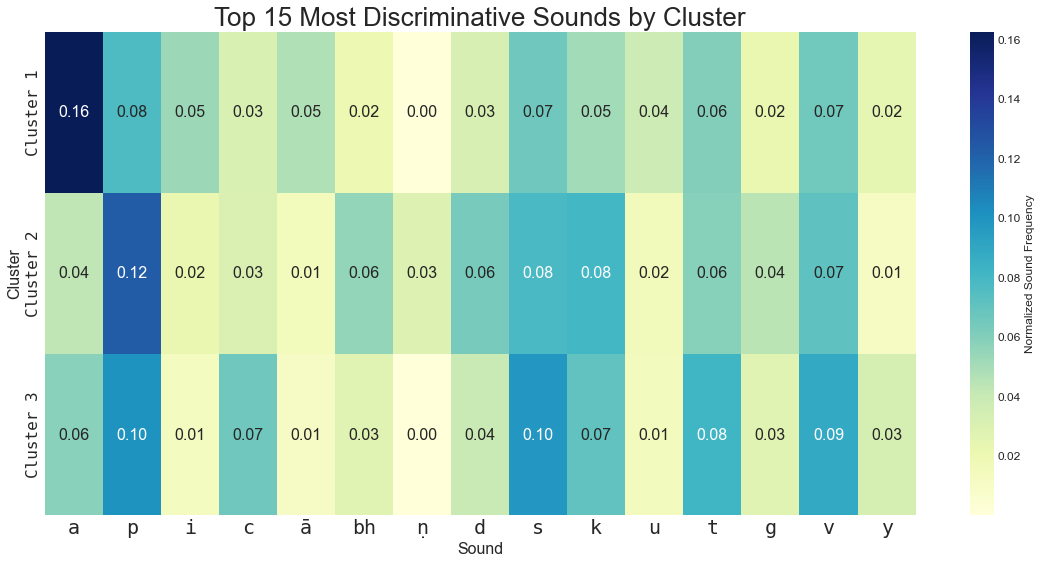

In [34]:
# Create a heatmap showing the most discriminative sounds by cluster
plt.figure(figsize=(16, 8))
top_sound_cols = top_features.head(15)['sound'].tolist()

# Create row labels (clusters)
row_labels = [f"Cluster {i+1}" for i in range(optimal_k)]

# Create the heatmap with annotations
sns.heatmap(centers_df[top_sound_cols], annot=True, fmt=".2f", cmap="YlGnBu",
            yticklabels=row_labels, 
            annot_kws={'rotation': 0, 'fontsize': 16, },
            cbar_kws={'label': 'Normalized Sound Frequency', 'orientation': 'vertical'},
            )
plt.title('Top 15 Most Discriminative Sounds by Cluster', fontsize=26)
plt.xlabel('Sound', fontsize=16)
plt.ylabel('Cluster', fontsize=16)
plt.xticks(rotation=0, fontsize=20, fontfamily='Monospace')
plt.yticks(rotation=90, fontsize=16, fontfamily='Monospace')
# Save the heatmap discriminative_sounds_by_cluster.png
plt.savefig('discriminative_sounds_by_cluster.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

## Visualization of Kavyas by Cluster

Let's visualize how the kavyas are distributed across the different clusters.

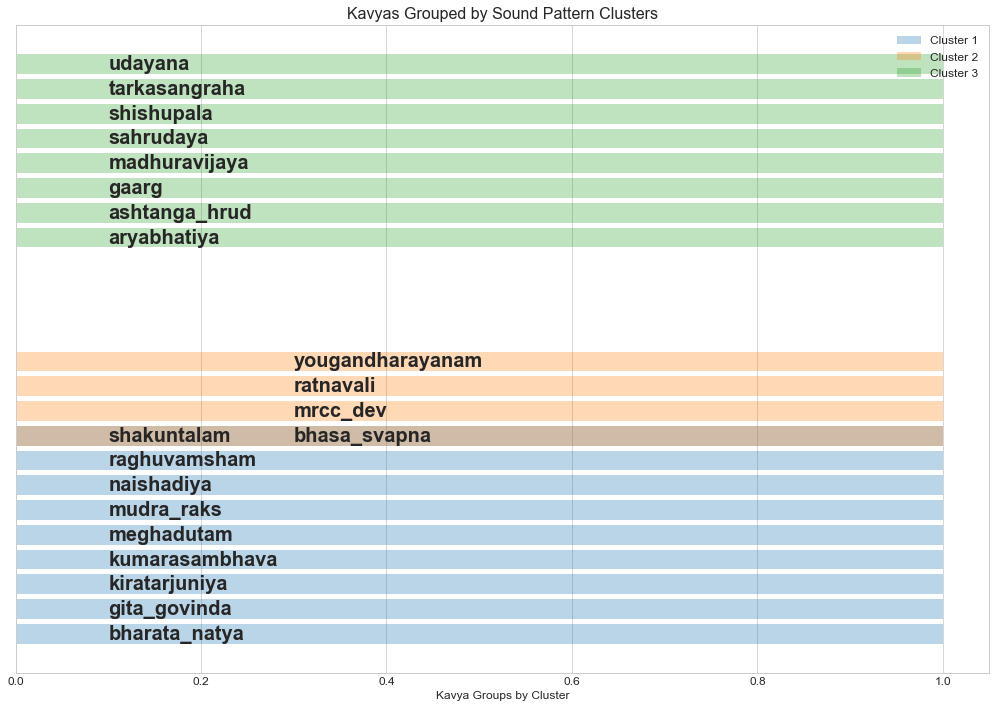

In [35]:
# Create a visualization showing the distribution of kavyas in each cluster
plt.figure(figsize=(14, 10))
for i, cluster_id in enumerate(np.sort(kavya_df['cluster'].unique())):
    kavyas_in_cluster = kavya_df[kavya_df['cluster'] == cluster_id]['kavya'].values
    y_positions = np.arange(len(kavyas_in_cluster)) + i * (len(kavya_df) / optimal_k + 1)
    plt.barh(y_positions, np.ones(len(kavyas_in_cluster)), height=0.8, 
             color=f'C{i}', alpha=0.3, label=f'Cluster {i+1}')
    for j, y in enumerate(y_positions):
        plt.text(0.1 + .2*(i%2), y, kavyas_in_cluster[j], va='center', fontsize=20, fontweight='bold')

plt.yticks([])
plt.xlabel('Kavya Groups by Cluster')
plt.title('Kavyas Grouped by Sound Pattern Clusters', fontsize=16)
plt.legend(loc='upper right')
# Save the kavya distribution plot -kavyas_by_cluster
plt.savefig('kavyas_by_cluster.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

## Hierarchical Clustering Visualization

Let's create a hierarchical clustering dendrogram to see another perspective on kavya sound patterns.

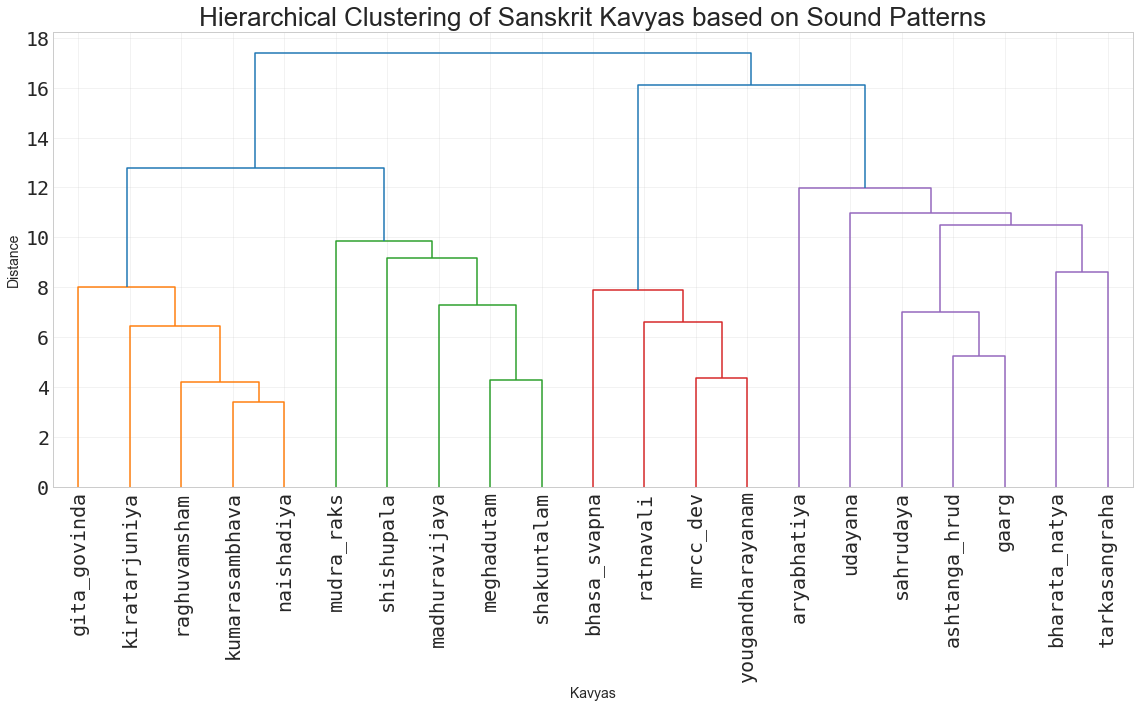

In [36]:
# Perform hierarchical clustering
linked = linkage(X_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(16, 10))
dendrogram(linked, 
           orientation='top', 
           labels=kavya_names,
           distance_sort=True,
           show_leaf_counts=True,
           leaf_font_size=12,
           )


plt.title('Hierarchical Clustering of Sanskrit Kavyas based on Sound Patterns', fontsize=26)
plt.xlabel('Kavyas', fontsize=14)
plt.ylabel('Distance', fontsize=14)
plt.xticks(rotation=90, fontsize=20, fontfamily='Monospace')
plt.yticks(fontsize=20, fontfamily='Monospace')
plt.grid(True, alpha=0.3)
# save kavya_dendrogram.png
plt.savefig('kavya_dendrogram.png', dpi=300, bbox_inches='tight')
# plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Force integer ticks on x-axis
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))  # Force integer ticks on y-axis

plt.tight_layout()

## Conclusion

This analysis has revealed distinct sound pattern clusters in Sanskrit kavyas. The most discriminative sounds between clusters include certain vowels and consonants that characterize different styles and periods of Sanskrit literature.

Key findings:
1. We identified optimal clusters of kavyas based on sound patterns
2. We found which sounds are most important for distinguishing between clusters
3. We visualized the relationships between kavyas in reduced-dimensional space
4. We created hierarchical clustering to show relationships between individual works

This analysis provides insights into the phonetic characteristics of different Sanskrit literary works and may reveal stylistic patterns across authors and periods.

In [74]:
# suppress warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy.cluster.hierarchy import dendrogram, linkage

def compute_variances(df, tag=""):
    df = df.set_index('kavya')
    variances = df.var()
    sorted_columns = variances.sort_values(ascending=False).index
    df_sorted = df[sorted_columns]
    # Heatmap: all scores
    plt.figure(figsize=(14, 8))
    sns.heatmap(df_sorted.map(lambda x: round(100*x,0)), cmap='Reds', annot=False)
    plt.title(f"{tag.capitalize()} - Sound Feature Variance Heatmap")
    plt.tight_layout()
    plt.savefig(f"{tag}_variance_heatmap.png")
    plt.show()
    return df_sorted

def run_clustering(df, tag="", force_optimal_k=None):
    X = df.drop('kavya', axis=1)
    kavya_names = df['kavya'].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    # Silhouette analysis
    sil_scores = []
    K_range = range(2, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        sil_score = silhouette_score(X_scaled, labels)
        sil_scores.append(sil_score)
    optimal_k = K_range[np.argmax(sil_scores)]
    
    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, sil_scores, 'o-', linewidth=2, markersize=8)
    plt.axvline(x=optimal_k, color='red', linestyle='--', label='Optimal k')
    if force_optimal_k:
        optimal_k = force_optimal_k
        plt.axvline(x=optimal_k, color='red', linestyle=':', label='Forced Optimal k')
    plt.legend()
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title(f'{tag.capitalize()} - Silhouette Score vs. Number of Clusters')
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.savefig(f"{tag}_silhouette_scores.png", dpi=300)
    plt.show()
    # KMeans with optimal k
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    # PCA for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plot_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Cluster': labels,
        'Kavya': kavya_names
    })
    # Plot clusters
    import matplotlib.cm as cm
    colors = cm.get_cmap('rainbow', optimal_k)
    # colors = matplotlib.colormaps['rainbow']
    markers = ['o', 's', '^', 'D', 'v', 'x', 'p', '*', 'h']
    plt.figure(figsize=(12, 8))
    for cluster in range(optimal_k):
        cluster_data = plot_df[plot_df['Cluster'] == cluster]
        plt.scatter(
            cluster_data['PC1'],
            cluster_data['PC2'],
            s=200,
            alpha=0.8,
            color=colors(cluster),
            edgecolor='black',
            linewidth=1.5,
            marker=markers[cluster % len(markers)],
            label=f'Cluster {cluster+1}'
        )
    for i, row in plot_df.iterrows():
        plt.annotate(
            row['Kavya'],
            (row['PC1'], row['PC2']),
            fontsize=12,
            xytext=(8, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            bbox=dict(boxstyle='round,pad=0.3', fc=colors(row['Cluster']), alpha=0.2),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='gray')
        )
    plt.xlabel(f'Principal Component 1')
    plt.ylabel(f'Principal Component 2')
    plt.title(f'{tag.capitalize()} - Clusters of Kavyas based on Sound Patterns')
    plt.legend(title='Clusters')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{tag}_clusters_pca.png", dpi=300)
    plt.show()
    return kmeans, labels, plot_df, scaler, X_scaled, pca, optimal_k

def analyze_cluster_centers(kmeans, scaler, X, tag=""):
    centers = kmeans.cluster_centers_
    centers_original = scaler.inverse_transform(centers)
    centers_df = pd.DataFrame(centers_original, columns=X.columns)
    # Heatmap of cluster centers
    plt.figure(figsize=(18, 10))
    sns.heatmap(centers_df, cmap='Reds', annot=True, fmt='.2f', cbar=False, linewidths=.5)
    plt.title(f'{tag.capitalize()} - Sound Patterns in Each Cluster')
    plt.xlabel('Sounds')
    plt.ylabel('Cluster')
    plt.xticks(rotation=0, fontsize=12, fontfamily='Monospace')
    plt.yticks(rotation=0, fontsize=12, fontfamily='Monospace')
    plt.tight_layout()
    plt.savefig(f"{tag}_cluster_centers_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()
    return centers_df

def plot_discriminative_sounds(centers_df, X, tag=""):
    feature_variance = pd.DataFrame({
        'sound': X.columns,
        'variance': np.var(centers_df.values, axis=0)
    })
    top_features = feature_variance.sort_values(by='variance', ascending=False).head(15)
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(x='sound', y='variance', data=top_features)
    plt.title(f'{tag.capitalize()} - Top 15 Most Discriminative Sounds', fontsize=18)
    plt.xlabel('Sound', fontsize=14)
    plt.ylabel('Variance Across Clusters', fontsize=14)
    plt.xticks(rotation=45, fontsize=12, fontfamily='Monospace')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points')
    plt.tight_layout()
    plt.savefig(f"{tag}_discriminative_sounds.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_hierarchical_clustering(X_scaled, kavya_names, tag=""):
    linked = linkage(X_scaled, method='ward')
    plt.figure(figsize=(16, 10))
    dendrogram(linked,
               orientation='top',
               labels=kavya_names,
               distance_sort=True,
               show_leaf_counts=True,
               leaf_font_size=12)
    plt.title(f'{tag.capitalize()} - Hierarchical Clustering of Kavyas', fontsize=18)
    plt.xlabel('Kavyas', fontsize=14)
    plt.ylabel('Distance', fontsize=14)
    plt.xticks(rotation=90, fontsize=12, fontfamily='Monospace')
    plt.yticks(fontsize=12, fontfamily='Monospace')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{tag}_kavya_dendrogram.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_feature_importance(plot_df, pca, feature_names, optimal_k, tag=""):
    """
    Visualizes kavyas in PCA space with clusters and overlays the top contributing sound features.
    Saves the plot as '{tag}_clusters_with_features.png'.
    
    Parameters:
        plot_df: DataFrame with columns ['PC1', 'PC2', 'Cluster', 'Kavya']
        pca: fitted PCA object (from sklearn)
        feature_names: list of feature (sound) names, in order matching PCA input
        optimal_k: number of clusters
        tag: string to prepend to output filename
    """
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np

    plt.figure(figsize=(14, 10))
    colors = cm.get_cmap('rainbow', optimal_k)
    markers = ['o', 's', '^', 'D', 'v', 'x', 'p', '*', 'h']

    # Scatter plot for clusters
    for cluster in range(optimal_k):
        cluster_data = plot_df[plot_df['Cluster'] == cluster]
        plt.scatter(
            cluster_data['PC1'], 
            cluster_data['PC2'], 
            s=200, 
            alpha=0.8, 
            label=f'Cluster {cluster+1}',
            color=colors(cluster),
            marker=markers[cluster % len(markers)]
        )

    # Add labels to points
    for i, row in plot_df.iterrows():
        plt.annotate(
            row['Kavya'],
            (row['PC1'], row['PC2']),
            fontsize=15,
            xytext=(8, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            bbox=dict(boxstyle='round,pad=0.3', fc=colors(row['Cluster']), alpha=0.1),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='gray')
        )

    # Feature vectors (eigenvectors scaled by eigenvalues)
    feature_vectors = np.transpose(pca.components_)
    feature_importance = np.abs(feature_vectors)
    top_features_idx = np.argsort(np.sum(feature_importance, axis=1))[-10:]
    scaling_factor = 20  # Adjust as needed for arrow length

    for i in top_features_idx:
        plt.arrow(0, 0, 
                  pca.components_[0, i] * scaling_factor, 
                  pca.components_[1, i] * scaling_factor, 
                  head_width=0.2, 
                  head_length=0.2, 
                  fc='red', 
                  ec='red', 
                  alpha=0.2)
        plt.text(pca.components_[0, i] * scaling_factor * 1.1, 
                 pca.components_[1, i] * scaling_factor * 1.1, 
                 feature_names[i], 
                 fontsize=18, 
                 color='darkred', 
                 ha='center', 
                 va='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.2))

    explained_variance = pca.explained_variance_ratio_
    plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1%} variance)')
    plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1%} variance)')
    plt.title(f'{tag.capitalize()} - Kavya Clusters with Top Contributing Sound Features', fontsize=16)
    plt.legend(title='Clusters')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{tag}_clusters_with_features.png', bbox_inches='tight')
    plt.show()

def full_sound_pattern_analysis(df, tag="", force_optimal_k=None):
    df_sorted = compute_variances(df.copy(), tag)
    kmeans, labels, plot_df, scaler, X_scaled,pca, optimal_k = run_clustering(df.copy(), tag, force_optimal_k)
    # if force_optimal_k: optimal_k = force_optimal_k
    centers_df = analyze_cluster_centers(kmeans, scaler, df.drop('kavya', axis=1), tag)
    plot_discriminative_sounds(centers_df, df.drop('kavya', axis=1), tag)
    plot_feature_importance(plot_df, pca, df.drop('kavya', axis=1).columns, optimal_k, tag)
    plot_hierarchical_clustering(X_scaled, df['kavya'].values, tag)
    print(f"Analysis complete for {tag}")


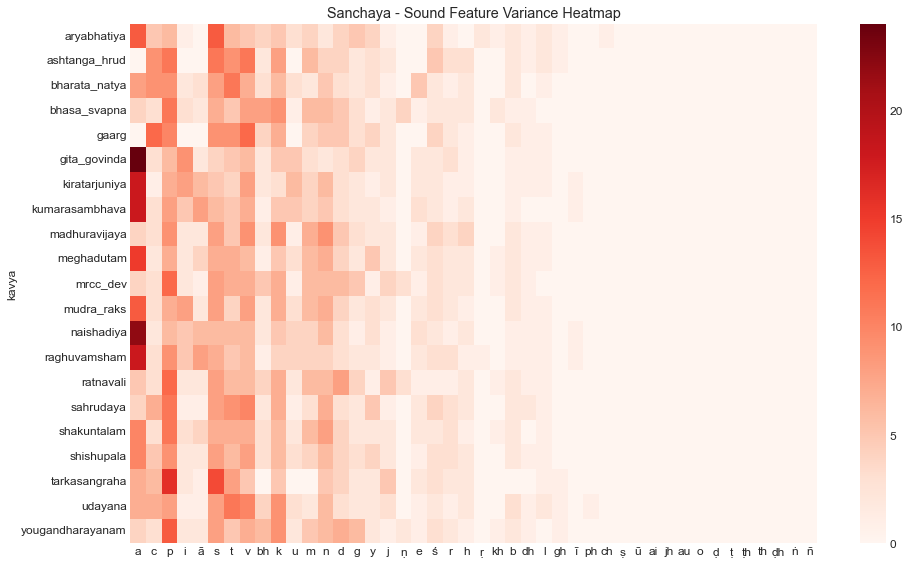

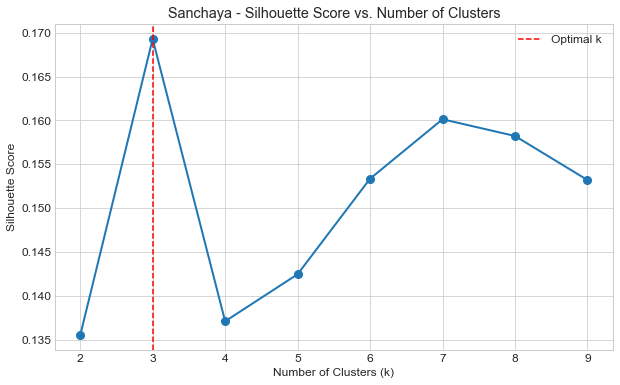

/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_49432/3302878603.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('rainbow', optimal_k)


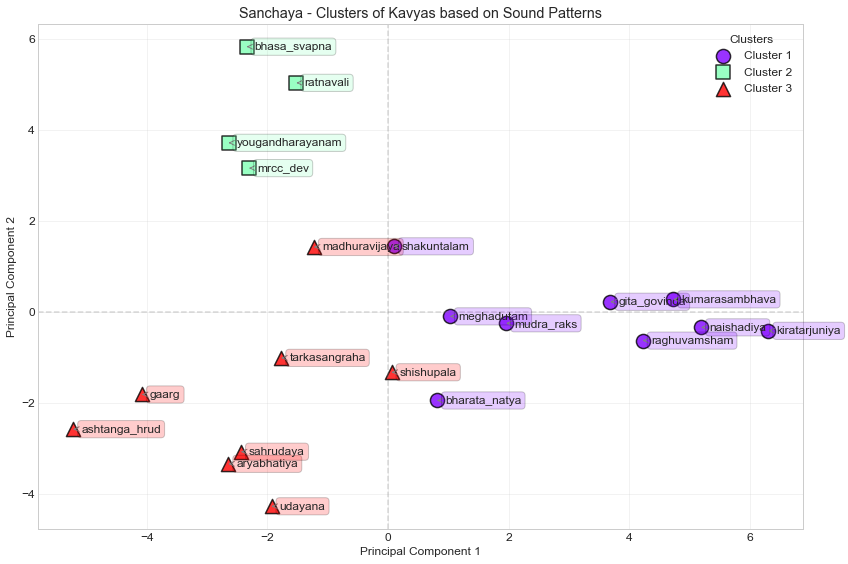

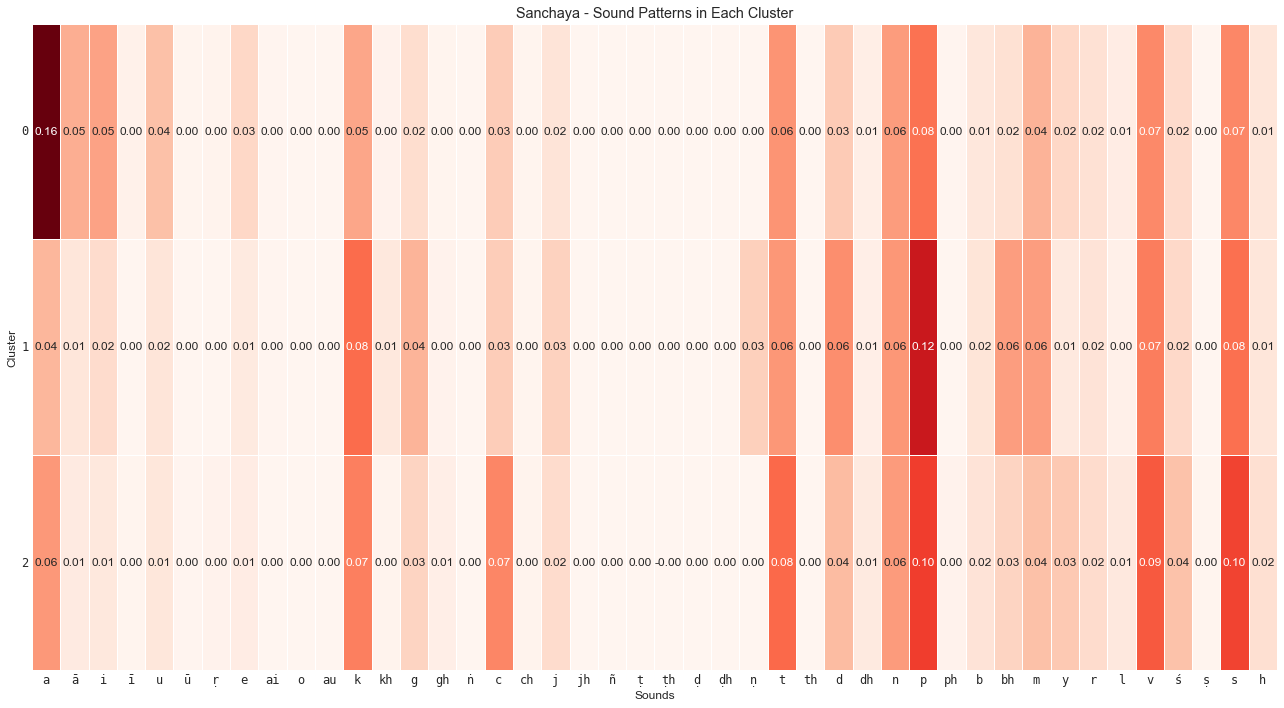

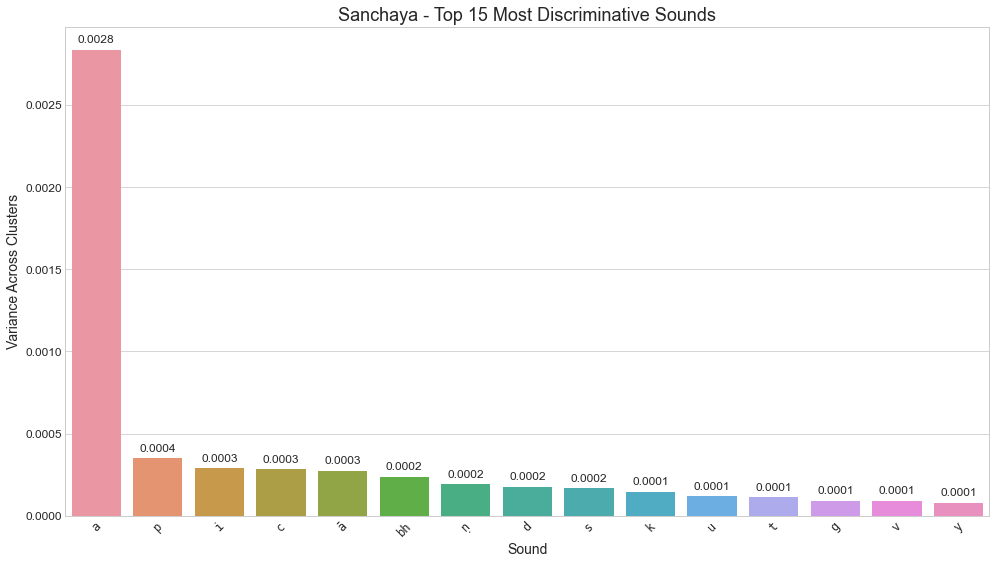

/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_49432/3302878603.py:191: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('rainbow', optimal_k)


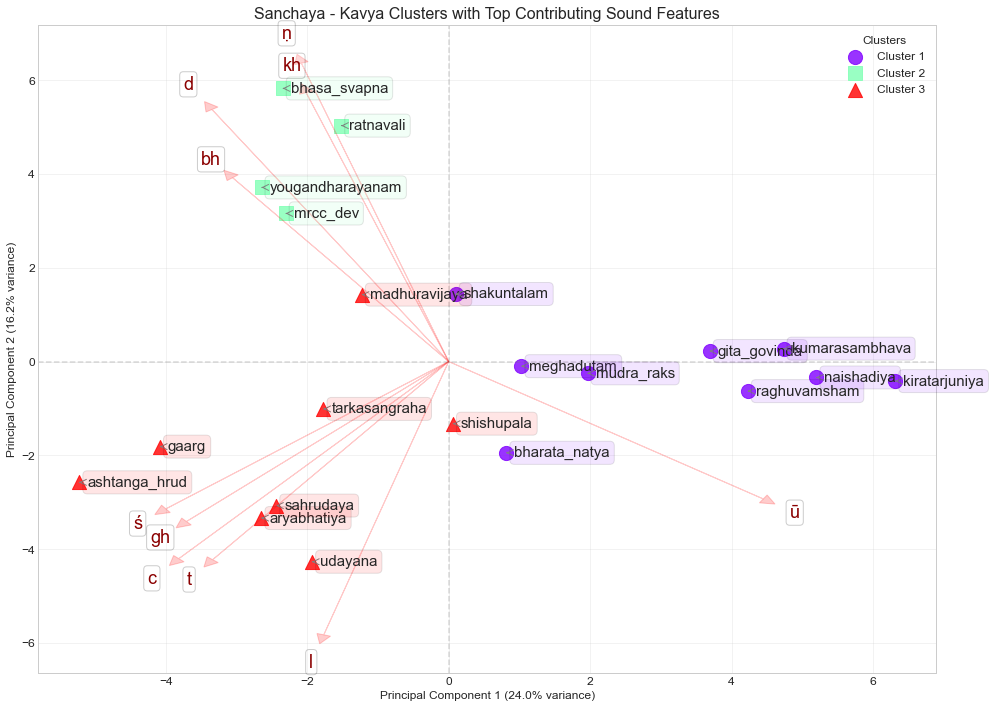

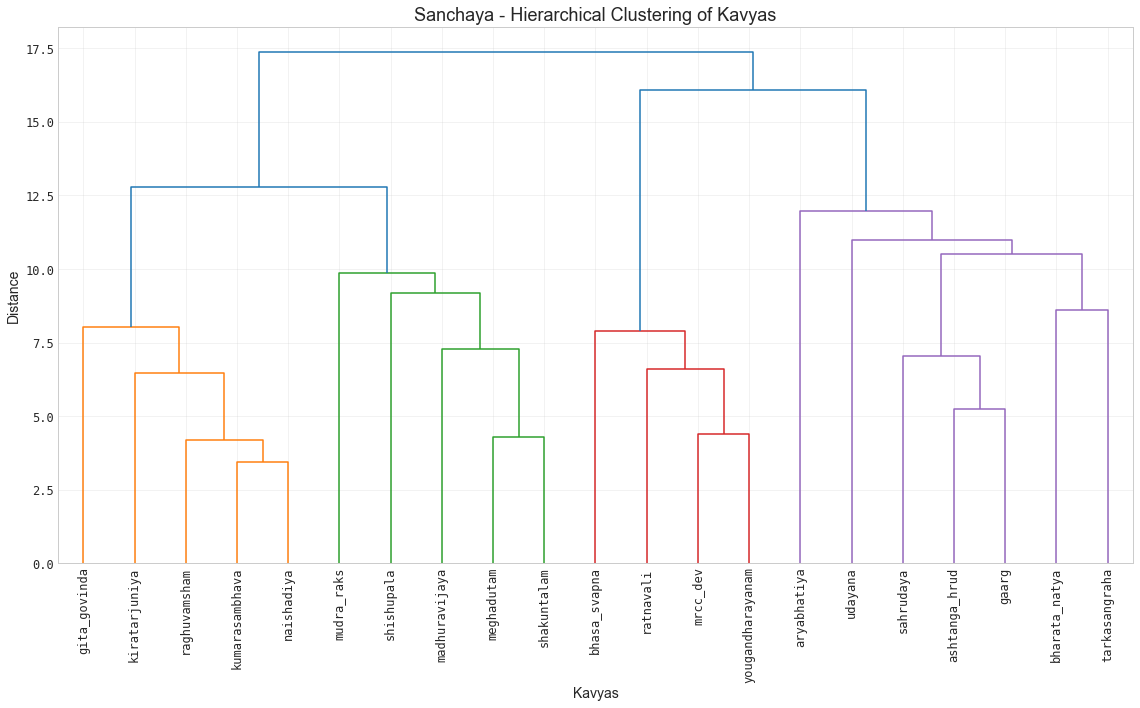

Analysis complete for sanchaya


In [73]:
sanchaya_data.columns = [transliterate(col, DEVANAGARI, IAST) for col in sanchaya_data.columns]
full_sound_pattern_analysis(sanchaya_data, tag="sanchaya")

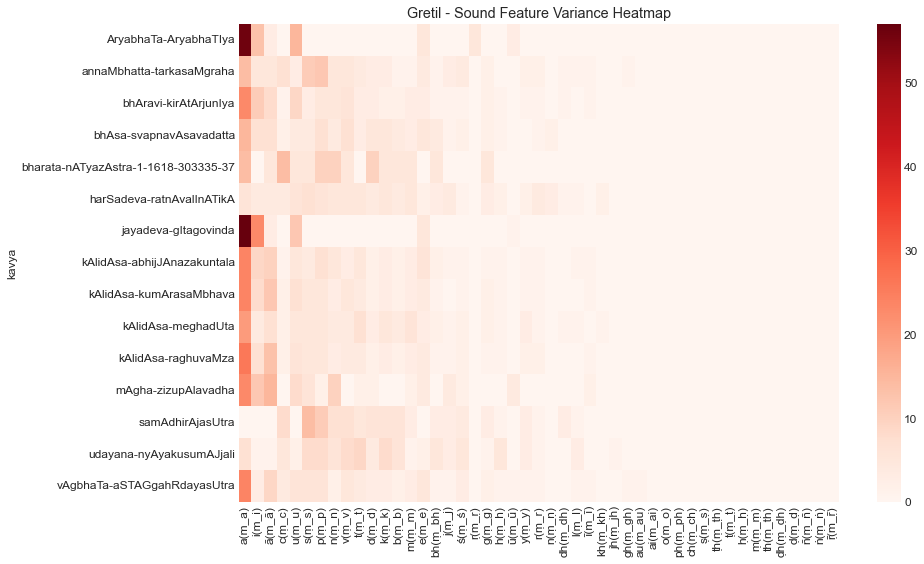

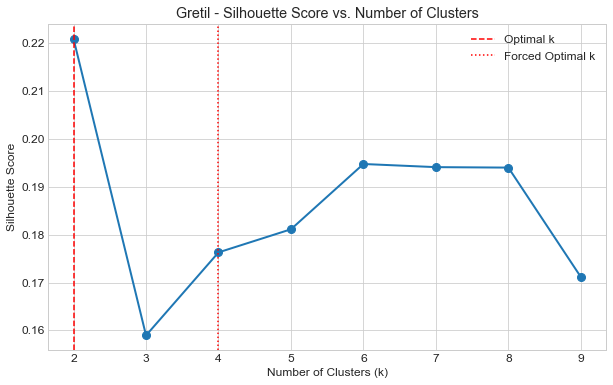

/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_49432/3302878603.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('rainbow', optimal_k)


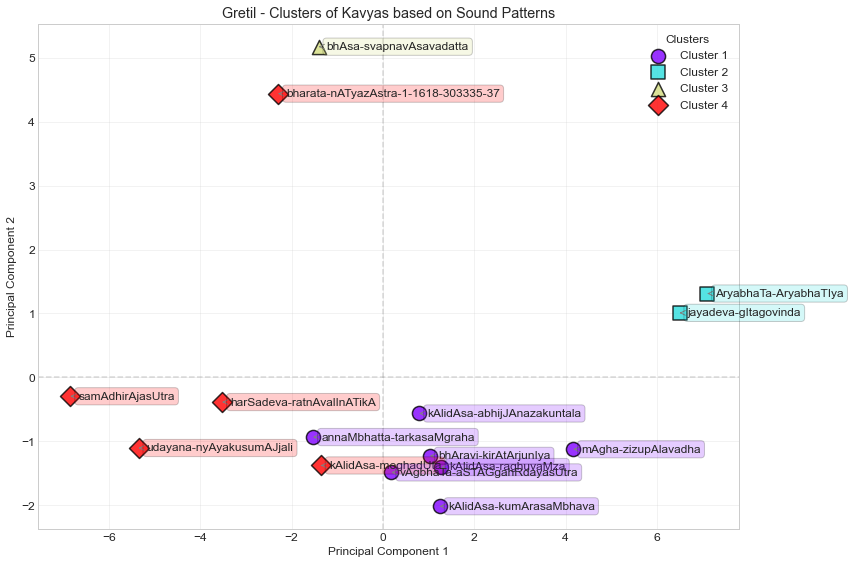

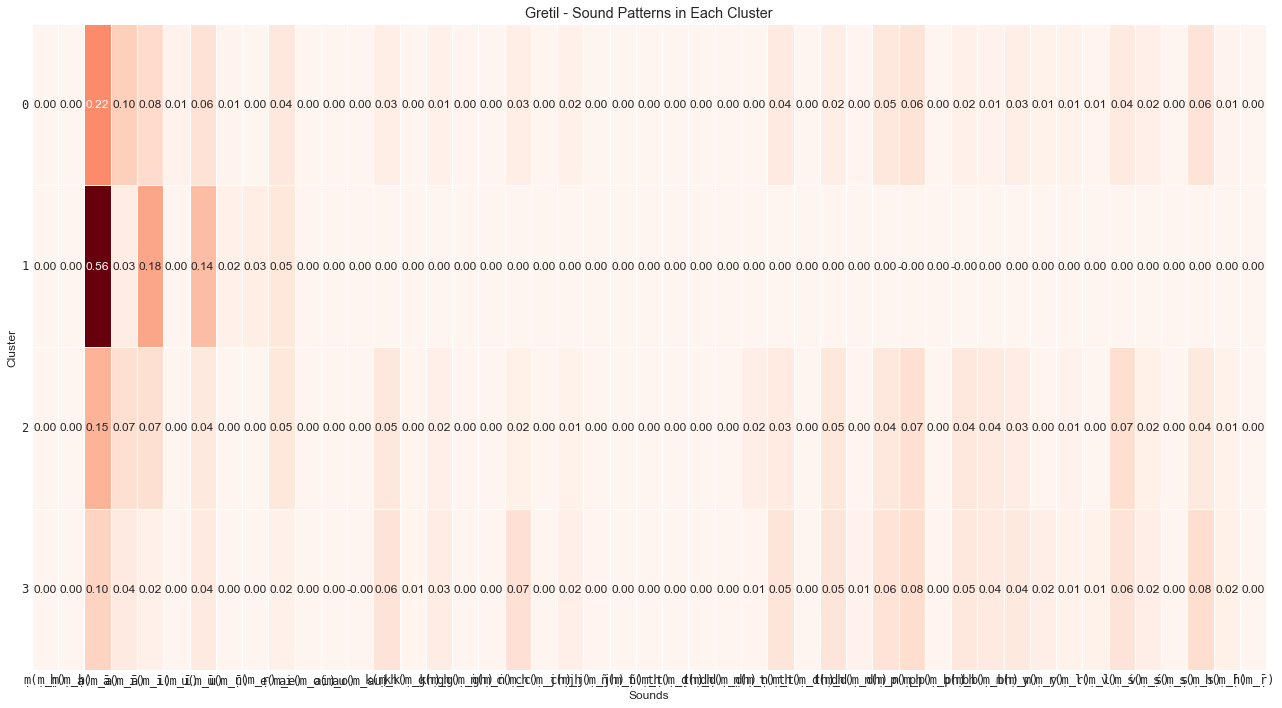

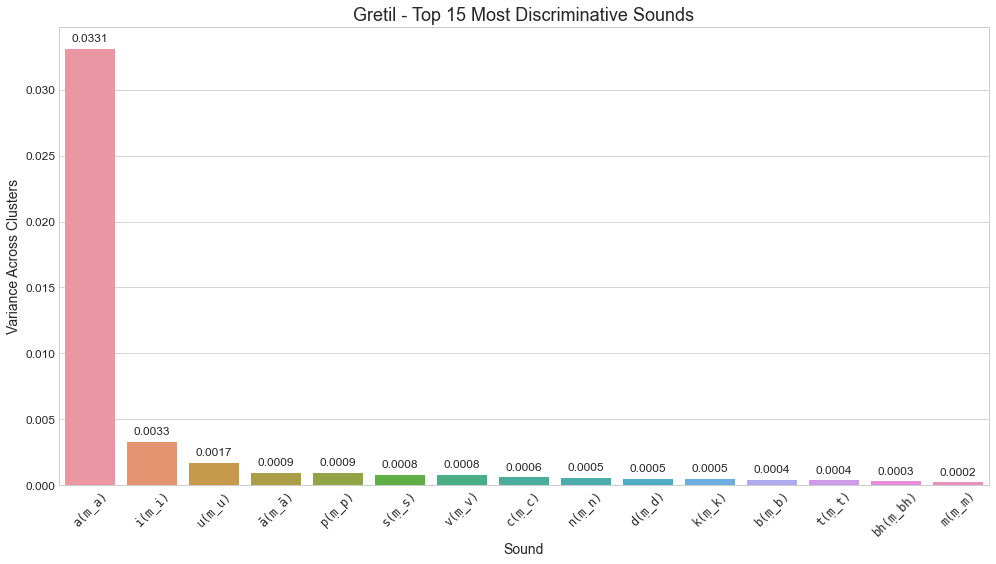

/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_49432/3302878603.py:191: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('rainbow', optimal_k)


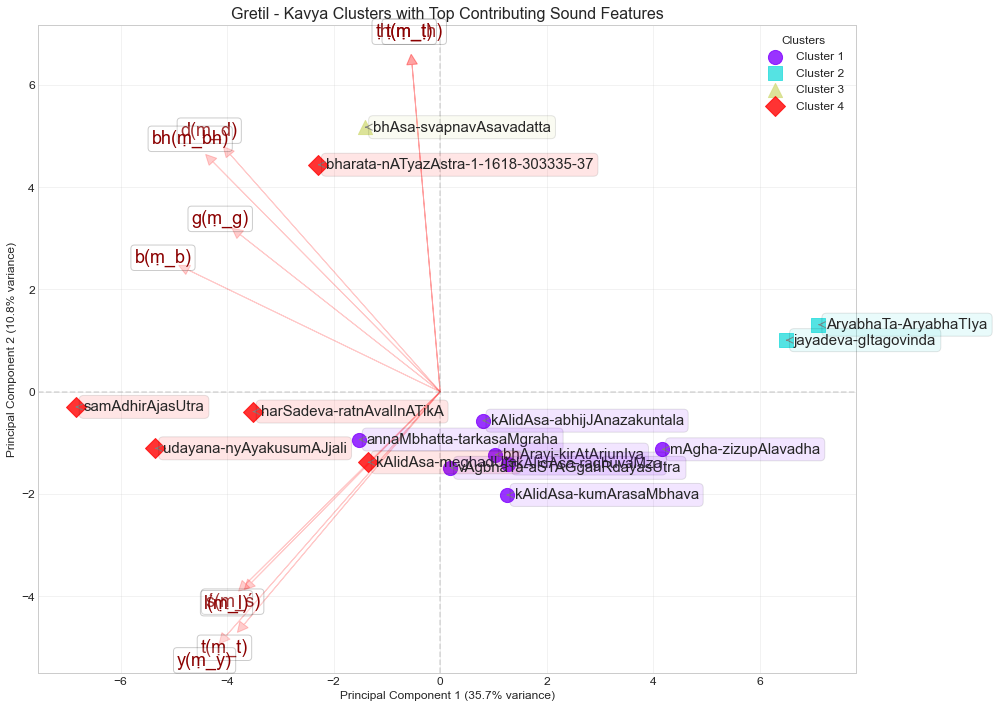

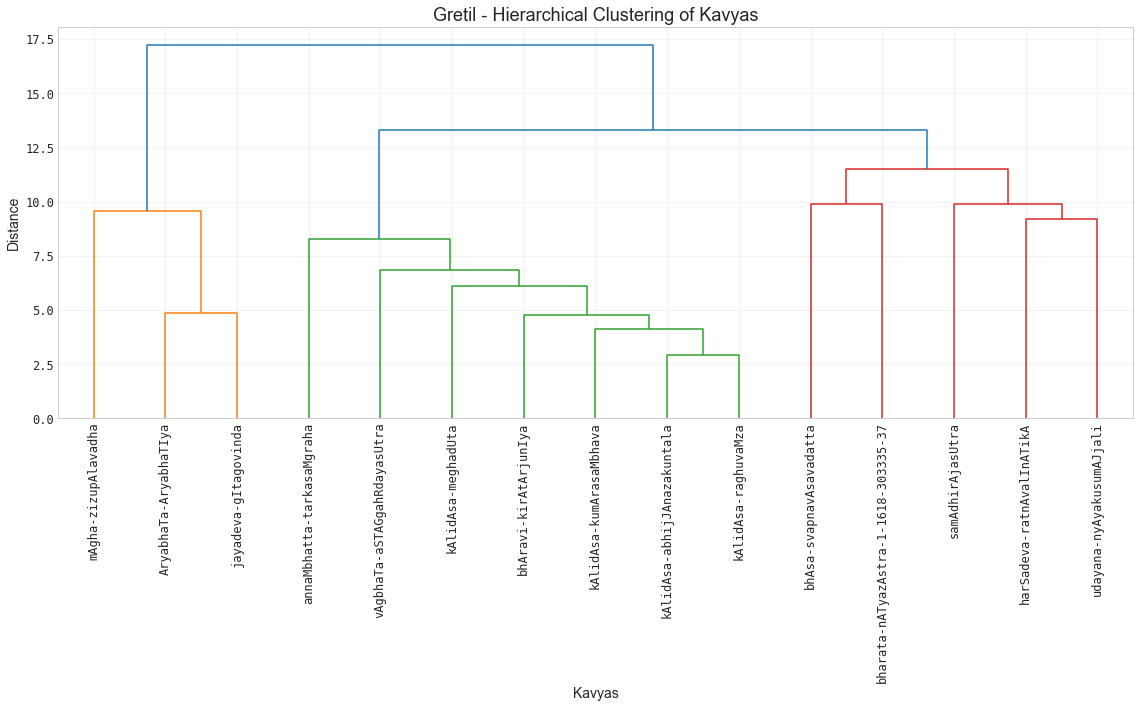

Analysis complete for gretil


In [76]:
gdata = selected_gretils_data.copy()
gdata.columns = [transliterate(col, DEVANAGARI, IAST) for col in gdata.columns]
full_sound_pattern_analysis(gdata, tag="gretil", force_optimal_k=4)
